# Getting Started with PyTorch for Machine Learning

Welcome to your PyTorch machine learning journey! This notebook will guide you through:
1. Verifying your Python environment
2. Installing and testing PyTorch
3. Checking GPU availability
4. Creating your first neural network
5. Running a simple training example

Let's get started! 🚀

## 1. Verify Python Installation

First, let's check your Python version. PyTorch works best with Python 3.8 or higher.

In [1]:
import sys
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

Python version: 3.14.2 (main, Dec  5 2025, 16:49:16) [Clang 17.0.0 (clang-1700.6.3.2)]
Python executable: /Users/jpan211/workspace/ml/venv/bin/python


## 2. Import PyTorch

Now let's import PyTorch and check that it's installed correctly.

In [2]:
import torch
import torchvision

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print("✓ PyTorch is successfully installed!")

PyTorch version: 2.10.0
Torchvision version: 0.25.0
✓ PyTorch is successfully installed!


## 3. Check GPU Availability (CUDA & MPS)

Let's check if a GPU is available for training. GPU acceleration can significantly speed up deep learning tasks.
- **CUDA**: For NVIDIA GPUs (Windows/Linux)
- **MPS**: For Apple Silicon (M1/M2/M3 Macs)

In [ ]:
# Check for CUDA (NVIDIA GPUs)
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

if cuda_available:
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
    print(f"✓ Using CUDA GPU")
else:
    # Check for MPS (Apple Silicon)
    mps_available = torch.backends.mps.is_available()
    print(f"MPS available: {mps_available}")

    if mps_available:
        device = torch.device("mps")
        print(f"✓ Using Apple Silicon GPU (MPS)")
    else:
        device = torch.device("cpu")
        print("Running on CPU. For better performance, consider using a GPU.")

print(f"\nDevice being used: {device}")

CUDA available: False
MPS available: True
✓ Using Apple Silicon GPU (MPS)

Device being used: mps


## 4. Import Common ML Libraries

Let's import the essential libraries we'll use for machine learning.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Matplotlib is building the font cache; this may take a moment.


✓ All libraries imported successfully!
NumPy version: 2.4.2
Pandas version: 3.0.1


## 5. PyTorch Tensor Basics

Tensors are the fundamental building blocks in PyTorch, similar to NumPy arrays but with GPU support and automatic differentiation capabilities.

In [6]:
# Create tensors in different ways
print("=== Creating Tensors ===\n")

# From a list
tensor_a = torch.tensor([[1, 2], [3, 4]])
print("Tensor from list:")
print(tensor_a)
print(f"Shape: {tensor_a.shape}, Data type: {tensor_a.dtype}\n")

# Random tensor
tensor_b = torch.randn(3, 4)
print("Random tensor (3x4):")
print(tensor_b)
print(f"Shape: {tensor_b.shape}\n")

# Zeros and ones
tensor_zeros = torch.zeros(2, 3)
tensor_ones = torch.ones(2, 3)
print("Zeros tensor:", tensor_zeros)
print("Ones tensor:", tensor_ones)

=== Creating Tensors ===

Tensor from list:
tensor([[1, 2],
        [3, 4]])
Shape: torch.Size([2, 2]), Data type: torch.int64

Random tensor (3x4):
tensor([[-0.4136, -1.4230, -0.6553, -1.4148],
        [-0.0385,  0.3687,  0.3090,  0.0342],
        [ 0.9899, -0.1092,  1.6674, -2.3197]])
Shape: torch.Size([3, 4])

Zeros tensor: tensor([[0., 0., 0.],
        [0., 0., 0.]])
Ones tensor: tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [7]:
# Tensor operations
print("=== Tensor Operations ===\n")

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
y = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

# Addition
print("Addition:")
print(x + y)
print()

# Element-wise multiplication
print("Element-wise multiplication:")
print(x * y)
print()

# Matrix multiplication
print("Matrix multiplication:")
print(torch.matmul(x, y))
print()

# Reshaping
print("Reshaping (2x2) -> (4,1):")
print(x.view(4, 1))

=== Tensor Operations ===

Addition:
tensor([[ 6.,  8.],
        [10., 12.]])

Element-wise multiplication:
tensor([[ 5., 12.],
        [21., 32.]])

Matrix multiplication:
tensor([[19., 22.],
        [43., 50.]])

Reshaping (2x2) -> (4,1):
tensor([[1.],
        [2.],
        [3.],
        [4.]])


## 6. Create a Simple Neural Network

Let's create a simple feedforward neural network for a classification task.

In [8]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Define a simple neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create an instance of the network
input_size = 10
hidden_size = 20
output_size = 3

model = SimpleNN(input_size, hidden_size, output_size).to(device)
print("Neural Network Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

Neural Network Architecture:
SimpleNN(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=3, bias=True)
)

Total parameters: 703


## 7. Test with Sample Data

Let's test our neural network with some random sample data to ensure everything works.

In [9]:
# Create sample data
sample_input = torch.randn(5, input_size).to(device)  # 5 samples
print("Sample input shape:", sample_input.shape)
print("Sample input:")
print(sample_input)

# Forward pass
with torch.no_grad():
    output = model(sample_input)

print(f"\nOutput shape: {output.shape}")
print("Output:")
print(output)

# Get predictions (argmax)
predictions = torch.argmax(output, dim=1)
print(f"\nPredicted classes: {predictions}")

Sample input shape: torch.Size([5, 10])
Sample input:
tensor([[-1.3710,  1.0138, -1.7700,  0.0448,  1.0240, -1.6384,  0.3113,  0.4535,
         -0.7293, -0.2809],
        [ 1.0143,  2.1523, -1.7407,  1.0217,  1.2069,  1.2521,  0.5537, -0.2131,
          1.4707,  1.3977],
        [ 0.0488,  1.5438, -0.0186,  2.1911,  0.7472, -0.9999, -0.3215,  0.2788,
          0.3871,  1.2220],
        [ 0.6407,  1.1132, -0.0561, -2.0969, -0.6799,  0.9349,  0.1829,  2.0995,
         -1.3668, -1.8007],
        [ 2.0350, -0.5191,  0.2677, -0.7096, -0.5662,  0.1792,  1.1210, -0.8436,
          0.1531, -2.0510]], device='mps:0')

Output shape: torch.Size([5, 3])
Output:
tensor([[ 0.3968,  0.1335,  0.1116],
        [ 0.3178,  0.0780,  0.0935],
        [ 0.3637,  0.1635,  0.0585],
        [ 0.5093, -0.0659, -0.0306],
        [ 0.3799,  0.0791,  0.0894]], device='mps:0')

Predicted classes: tensor([0, 0, 0, 0, 0], device='mps:0')


## 8. Train on Synthetic Data

Now let's train the network on some synthetic data to see it learning in action!

In [10]:
# Generate synthetic dataset
torch.manual_seed(42)
num_samples = 1000

# Create features and labels
X_train = torch.randn(num_samples, input_size).to(device)
y_train = torch.randint(0, output_size, (num_samples,)).to(device)

# Create a new model instance
model = SimpleNN(input_size, hidden_size, output_size).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) # learning rate

# Training loop
num_epochs = 50
batch_size = 32
losses = []

print("Training started...")
for epoch in range(num_epochs):
    epoch_loss = 0

    # Mini-batch training
    for i in range(0, num_samples, batch_size):
        batch_X = X_train[i:i+batch_size]
        batch_y = y_train[i:i+batch_size]

        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (num_samples / batch_size)
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("✓ Training completed!")

Training started...
Epoch [10/50], Loss: 0.9795
Epoch [20/50], Loss: 0.8300
Epoch [30/50], Loss: 0.7399
Epoch [40/50], Loss: 0.6642
Epoch [50/50], Loss: 0.6155
✓ Training completed!


## 9. Visualize Training Progress

Let's plot the loss curve to see how the model improved during training.

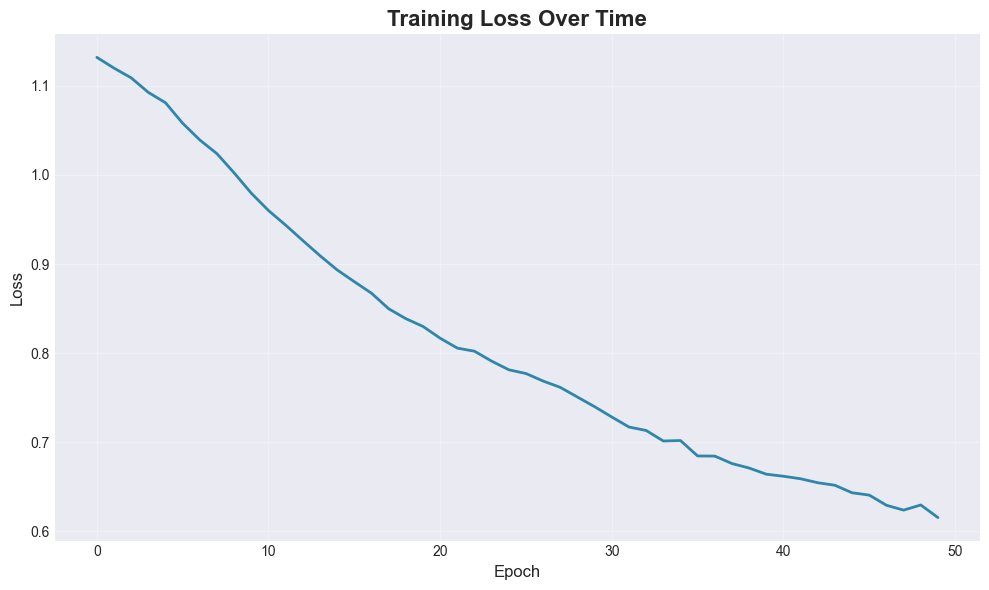

Initial Loss: 1.1320
Final Loss: 0.6155
Loss Reduction: 45.62%


In [11]:
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, color='#2E86AB')
plt.title('Training Loss Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial Loss: {losses[0]:.4f}")
print(f"Final Loss: {losses[-1]:.4f}")
print(f"Loss Reduction: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

## 🎉 Congratulations!

You've successfully:
- ✅ Set up your PyTorch environment
- ✅ Learned about PyTorch tensors and operations
- ✅ Created a neural network from scratch
- ✅ Trained a model and visualized the results

### Next Steps

1. **Learn more about PyTorch:**
   - Explore different activation functions (ReLU, Sigmoid, Tanh)
   - Try different optimizers (SGD, RMSprop, AdamW)
   - Learn about learning rate scheduling

2. **Work with real datasets:**
   - MNIST for digit recognition
   - CIFAR-10 for image classification
   - Custom datasets for your projects

3. **Advanced topics:**
   - Convolutional Neural Networks (CNNs)
   - Recurrent Neural Networks (RNNs)
   - Transfer Learning
   - Model saving and loading

Keep experimenting and happy learning! 🚀